In [1]:
# 셀 1: 라이브러리 import, zip 파일 경로 설정, 압축 해제
import os
import zipfile
import warnings
warnings.filterwarnings('ignore')

import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns

plt.style.use('default')
pd.set_option('display.max_columns', None)
pd.set_option('display.max_rows', 200)

# 업로드한 zip 파일명
zip_path = '/content/binary-classification-with-a-bank-dataset-clone.zip'

# 압축 해제 폴더
extract_path = '/content/bank_competition_data'
os.makedirs(extract_path, exist_ok=True)

# zip 압축 해제
with zipfile.ZipFile(zip_path, 'r') as zip_ref:
    zip_ref.extractall(extract_path)

print("압축 해제 완료")
print("압축 해제 경로:", extract_path)
print("폴더 내 파일 목록:", os.listdir(extract_path))

압축 해제 완료
압축 해제 경로: /content/bank_competition_data
폴더 내 파일 목록: ['train.csv', 'sample_submission.csv', 'test.csv']


In [2]:
# 셀 2: train, test, submission 파일 불러오기
train_path = os.path.join(extract_path, 'train.csv')
test_path = os.path.join(extract_path, 'test.csv')
sub_path = os.path.join(extract_path, 'sample_submission.csv')

train = pd.read_csv(train_path)
test = pd.read_csv(test_path)
sample_submission = pd.read_csv(sub_path)

print("train shape:", train.shape)
print("test shape:", test.shape)
print("sample_submission shape:", sample_submission.shape)

train shape: (750000, 18)
test shape: (250000, 17)
sample_submission shape: (250000, 2)


In [3]:
# 셀 3: 데이터 미리보기
print("=== train head ===")
display(train.head())

print("=== test head ===")
display(test.head())

print("=== sample_submission head ===")
display(sample_submission.head())

print("=== train columns ===")
print(train.columns.tolist())

=== train head ===


,id,age,job,marital,education,default,balance,housing,loan,contact,day,month,duration,campaign,pdays,previous,poutcome,y
0,0,42,technician,married,secondary,no,7,no,no,cellular,25,aug,117,3,-1,0,unknown,0
1,1,38,blue-collar,married,secondary,no,514,no,no,unknown,18,jun,185,1,-1,0,unknown,0
2,2,36,blue-collar,married,secondary,no,602,yes,no,unknown,14,may,111,2,-1,0,unknown,0
3,3,27,student,single,secondary,no,34,yes,no,unknown,28,may,10,2,-1,0,unknown,0
4,4,26,technician,married,secondary,no,889,yes,no,cellular,3,feb,902,1,-1,0,unknown,1


=== test head ===


,id,age,job,marital,education,default,balance,housing,loan,contact,day,month,duration,campaign,pdays,previous,poutcome
0,750000,32,blue-collar,married,secondary,no,1397,yes,no,unknown,21,may,224,1,-1,0,unknown
1,750001,44,management,married,tertiary,no,23,yes,no,cellular,3,apr,586,2,-1,0,unknown
2,750002,36,self-employed,married,primary,no,46,yes,yes,cellular,13,may,111,2,-1,0,unknown
3,750003,58,blue-collar,married,secondary,no,-1380,yes,yes,unknown,29,may,125,1,-1,0,unknown
4,750004,28,technician,single,secondary,no,1950,yes,no,cellular,22,jul,181,1,-1,0,unknown


=== sample_submission head ===


,id,y
0,750000,0.5
1,750001,0.5
2,750002,0.5
3,750003,0.5
4,750004,0.5


=== train columns ===
['id', 'age', 'job', 'marital', 'education', 'default', 'balance', 'housing', 'loan', 'contact', 'day', 'month', 'duration', 'campaign', 'pdays', 'previous', 'poutcome', 'y']


In [4]:
# 셀 4: 데이터 타입, non-null 개수, 메모리 등 기본 정보 확인
print("=== train info ===")
train.info()

print("\n=== test info ===")
test.info()

=== train info ===
<class 'pandas.core.frame.DataFrame'>
RangeIndex: 750000 entries, 0 to 749999
Data columns (total 18 columns):
 #   Column     Non-Null Count   Dtype 
---  ------     --------------   ----- 
 0   id         750000 non-null  int64 
 1   age        750000 non-null  int64 
 2   job        750000 non-null  object
 3   marital    750000 non-null  object
 4   education  750000 non-null  object
 5   default    750000 non-null  object
 6   balance    750000 non-null  int64 
 7   housing    750000 non-null  object
 8   loan       750000 non-null  object
 9   contact    750000 non-null  object
 10  day        750000 non-null  int64 
 11  month      750000 non-null  object
 12  duration   750000 non-null  int64 
 13  campaign   750000 non-null  int64 
 14  pdays      750000 non-null  int64 
 15  previous   750000 non-null  int64 
 16  poutcome   750000 non-null  object
 17  y          750000 non-null  int64 
dtypes: int64(9), object(9)
memory usage: 103.0+ MB

=== test info ===

In [5]:
# 셀 5: 결측치 개수와 비율 확인
def missing_table(df):
    miss_cnt = df.isnull().sum()
    miss_ratio = (df.isnull().mean() * 100).round(2)
    result = pd.DataFrame({
        'missing_count': miss_cnt,
        'missing_ratio(%)': miss_ratio
    }).sort_values(by='missing_count', ascending=False)
    return result[result['missing_count'] > 0]

print("=== train 결측치 ===")
display(missing_table(train))

print("=== test 결측치 ===")
display(missing_table(test))

=== train 결측치 ===


,missing_count,missing_ratio(%)


=== test 결측치 ===


,missing_count,missing_ratio(%)


In [6]:
# 셀 6: 문자열 컬럼에서 'unknown' 값 점검
obj_cols = train.select_dtypes(include='object').columns.tolist()

unknown_summary = []
for col in obj_cols:
    unknown_cnt = (train[col] == 'unknown').sum()
    unknown_ratio = round(unknown_cnt / len(train) * 100, 2)
    unknown_summary.append([col, unknown_cnt, unknown_ratio])

unknown_df = pd.DataFrame(unknown_summary, columns=['column', 'unknown_count', 'unknown_ratio(%)'])
unknown_df = unknown_df.sort_values(by='unknown_count', ascending=False)

print("=== train 문자열 컬럼 내 'unknown' 점검 ===")
display(unknown_df)

=== train 문자열 컬럼 내 'unknown' 점검 ===


,column,unknown_count,unknown_ratio(%)
8,poutcome,672450,89.66
6,contact,231627,30.88
2,education,21299,2.84
0,job,2917,0.39
1,marital,0,0.00
4,housing,0,0.00
3,default,0,0.00
5,loan,0,0.00
7,month,0,0.00


In [7]:
# 셀 7: 수치형 변수와 범주형 변수 구분
target_col = 'y'
id_col = 'id'

num_cols = train.select_dtypes(include=np.number).columns.tolist()
cat_cols = train.select_dtypes(include='object').columns.tolist()

if target_col in num_cols:
    num_cols.remove(target_col)
if id_col in num_cols:
    num_cols.remove(id_col)

print("수치형 변수:", num_cols)
print("범주형 변수:", cat_cols)
print("타깃 변수:", target_col)
print("ID 변수:", id_col)

수치형 변수: ['age', 'balance', 'day', 'duration', 'campaign', 'pdays', 'previous']
범주형 변수: ['job', 'marital', 'education', 'default', 'housing', 'loan', 'contact', 'month', 'poutcome']
타깃 변수: y
ID 변수: id


In [8]:
# 셀 8: 수치형 변수 기초통계량 확인
print("=== 수치형 변수 기초통계 ===")
display(train[num_cols].describe().T)

=== 수치형 변수 기초통계 ===


,count,mean,std,min,25%,50%,75%,max
age,750000.0,40.926395,10.098829,18.0,33.0,39.0,48.0,95.0
balance,750000.0,1204.067397,2836.096759,-8019.0,0.0,634.0,1390.0,99717.0
day,750000.0,16.117209,8.250832,1.0,9.0,17.0,21.0,31.0
duration,750000.0,256.229144,272.555662,1.0,91.0,133.0,361.0,4918.0
campaign,750000.0,2.577008,2.718514,1.0,1.0,2.0,3.0,63.0
pdays,750000.0,22.412733,77.319998,-1.0,-1.0,-1.0,-1.0,871.0
previous,750000.0,0.298545,1.335926,0.0,0.0,0.0,0.0,200.0


=== 타깃 분포 ===


,count,ratio(%)
y,,
0,659512,87.93
1,90488,12.07


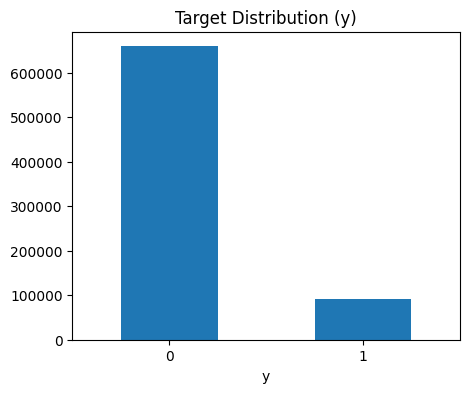

In [9]:
# 셀 9: 타깃 분포 확인
target_dist = train[target_col].value_counts().sort_index()
target_ratio = train[target_col].value_counts(normalize=True).sort_index() * 100

target_summary = pd.DataFrame({
    'count': target_dist,
    'ratio(%)': target_ratio.round(2)
})

print("=== 타깃 분포 ===")
display(target_summary)

plt.figure(figsize=(5, 4))
train[target_col].value_counts().sort_index().plot(kind='bar')
plt.title('Target Distribution (y)')
plt.xticks(rotation=0)
plt.show()

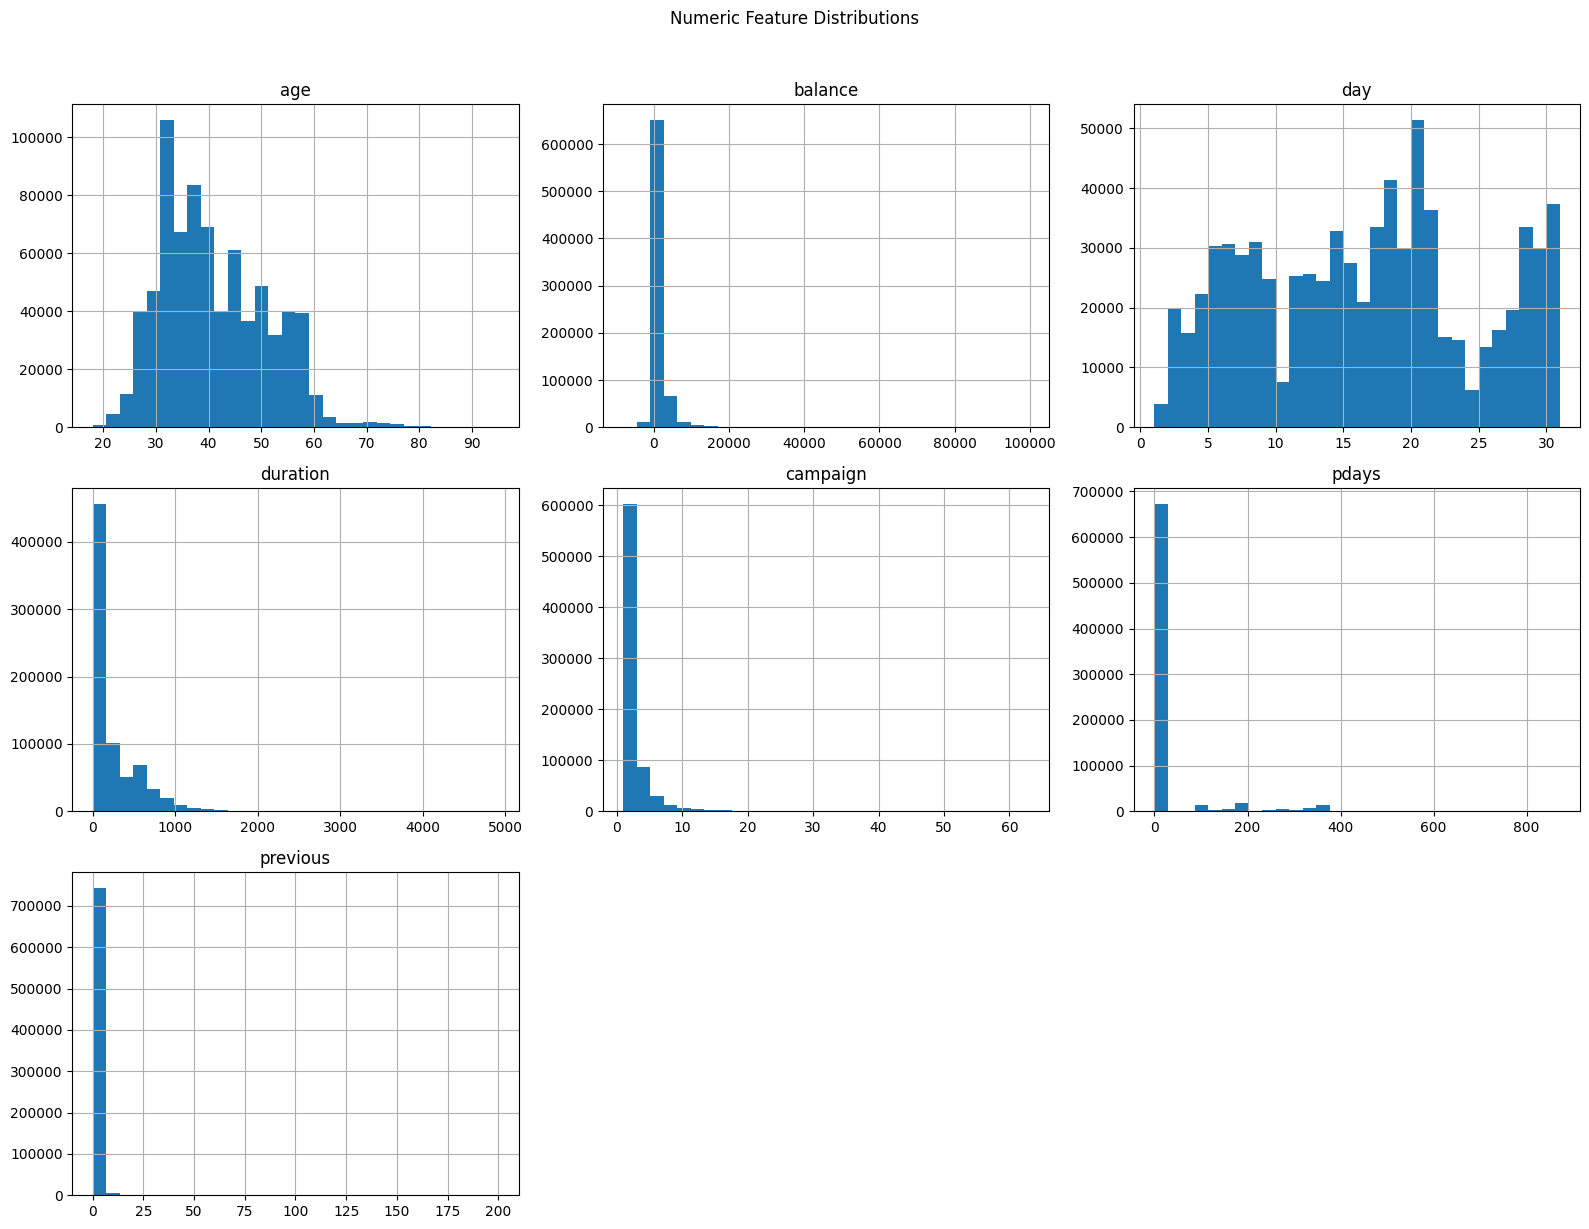

In [10]:
# 셀 10: 수치형 변수 히스토그램 확인
train[num_cols].hist(figsize=(16, 12), bins=30)
plt.suptitle('Numeric Feature Distributions', y=1.02)
plt.tight_layout()
plt.show()

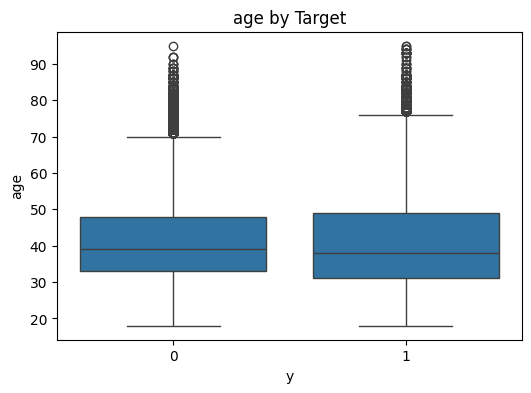

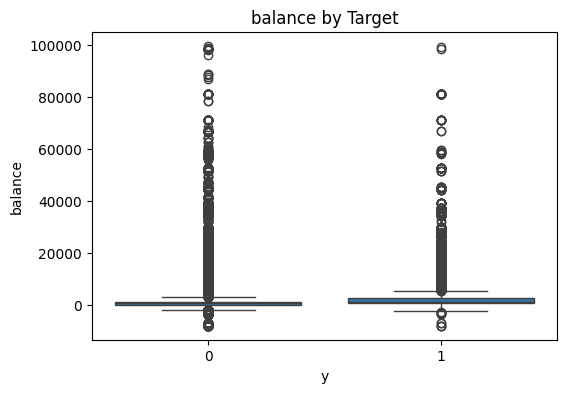

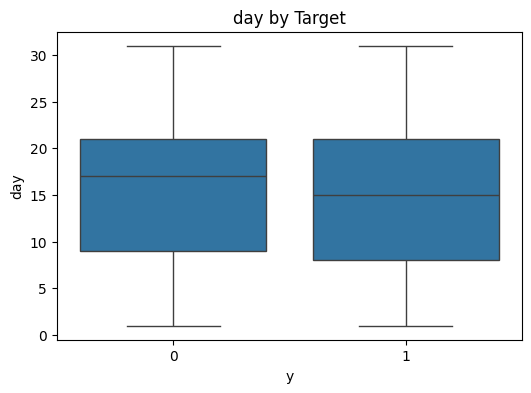

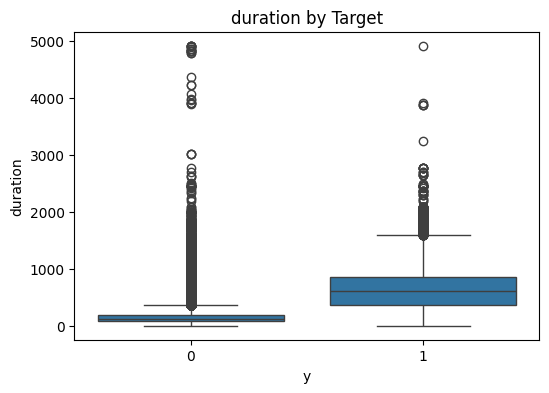

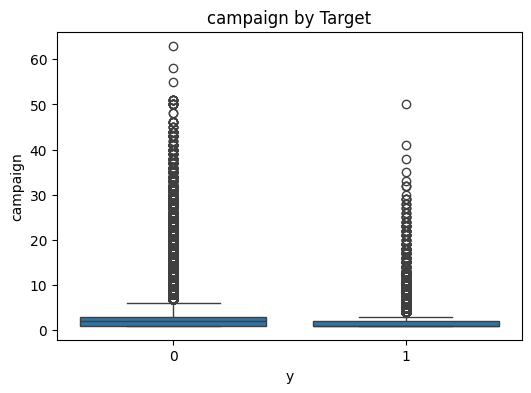

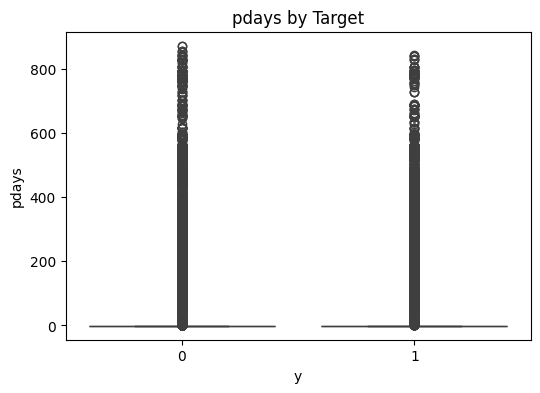

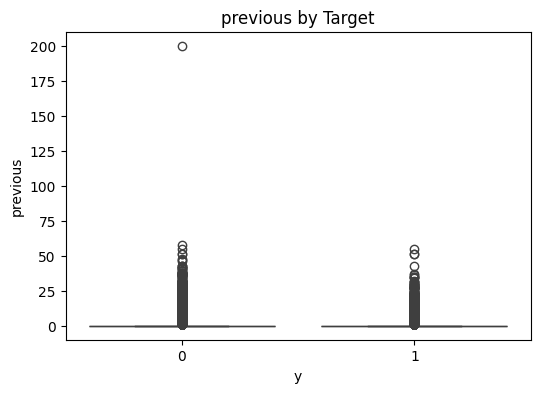

In [11]:
# 셀 11: 수치형 변수별 타깃(y) 분포 비교 박스플롯
for col in num_cols:
    plt.figure(figsize=(6, 4))
    sns.boxplot(data=train, x=target_col, y=col)
    plt.title(f'{col} by Target')
    plt.show()

In [12]:
# 셀 12: 범주형 변수별 고유값 개수 및 상위 빈도 확인
cat_summary = []

for col in cat_cols:
    cat_summary.append([
        col,
        train[col].nunique(),
        train[col].mode()[0],
        train[col].value_counts().iloc[0]
    ])

cat_summary_df = pd.DataFrame(cat_summary, columns=['column', 'n_unique', 'top_value', 'top_count'])
cat_summary_df = cat_summary_df.sort_values(by='n_unique', ascending=False)

print("=== 범주형 변수 요약 ===")
display(cat_summary_df)

=== 범주형 변수 요약 ===


,column,n_unique,top_value,top_count
0,job,12,management,175541
7,month,12,may,228411
2,education,4,secondary,401683
8,poutcome,4,unknown,672450
1,marital,3,married,480759
6,contact,3,cellular,486655
3,default,2,no,737151
4,housing,2,yes,411288
5,loan,2,no,645023


In [13]:
# 셀 13: 범주형 변수별 타깃 평균(가입률) 확인
for col in cat_cols:
    temp = train.groupby(col)[target_col].agg(['count', 'mean']).sort_values(by='mean', ascending=False)
    temp['mean'] = temp['mean'].round(4)
    print(f"\n=== {col}별 타깃 평균 ===")
    display(temp)


=== job별 타깃 평균 ===


,count,mean
job,,
student,11767,0.3408
retired,35185,0.2462
unemployed,17634,0.1798
management,175541,0.1504
self-employed,19020,0.1294
unknown,2917,0.1207
technician,138107,0.1183
admin.,81492,0.1165
housemaid,15912,0.0847



=== marital별 타깃 평균 ===


,count,mean
marital,,
single,194834,0.1705
divorced,74407,0.1116
married,480759,0.1019



=== education별 타깃 평균 ===


...

,count,mean
contact,,
cellular,486655,0.1566
telephone,31718,0.1368
unknown,231627,0.0430



=== month별 타깃 평균 ===


,count,mean
month,,
mar,5802,0.5714
sep,7409,0.5348
dec,2069,0.5133
oct,9204,0.4900
apr,41319,0.2357
feb,37611,0.2068
jan,18937,0.1241
aug,128859,0.1122
nov,66062,0.1098



=== poutcome별 타깃 평균 ===


,count,mean
poutcome,,
success,17691,0.7640
other,14744,0.1668
failure,45115,0.1328
unknown,672450,0.1019


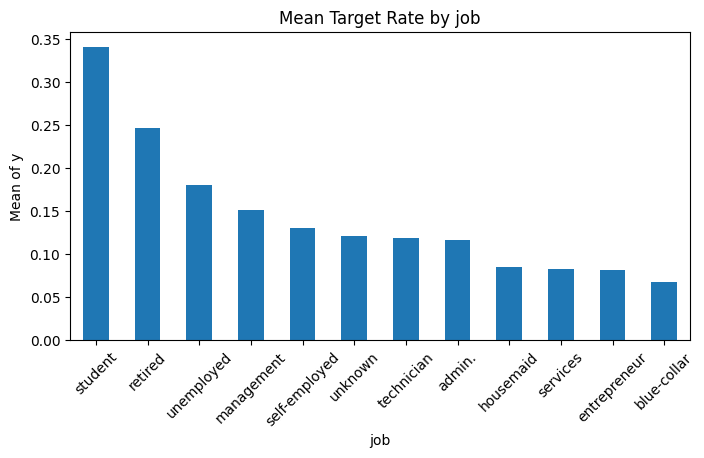

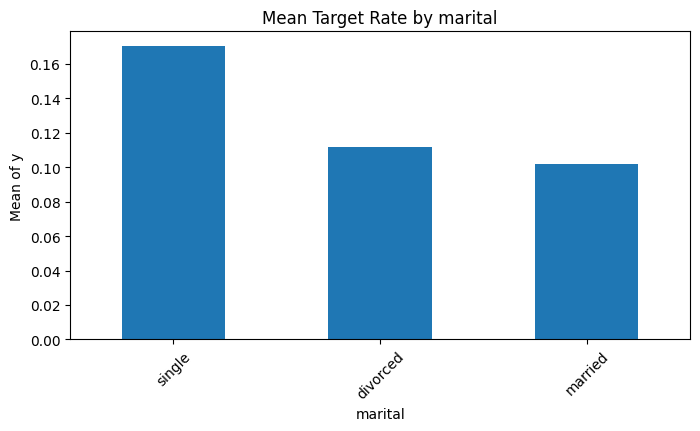

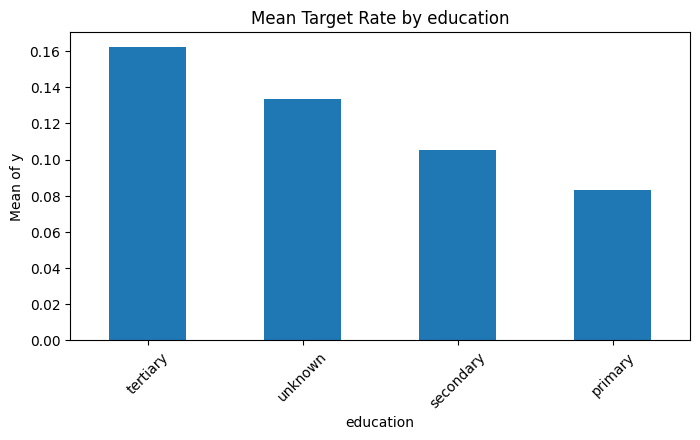

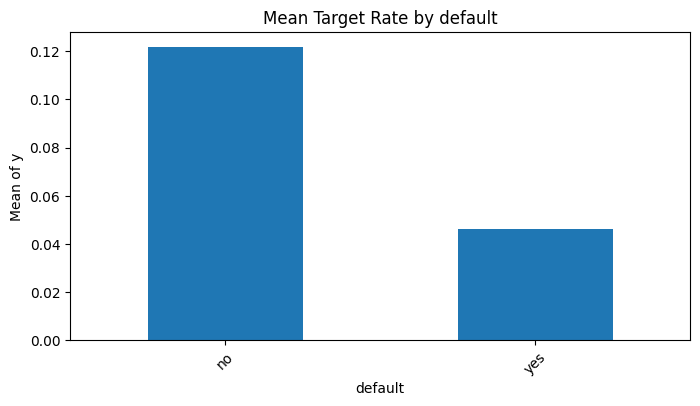

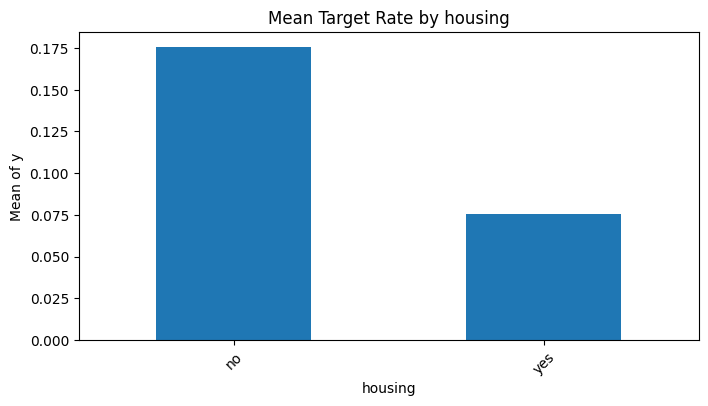

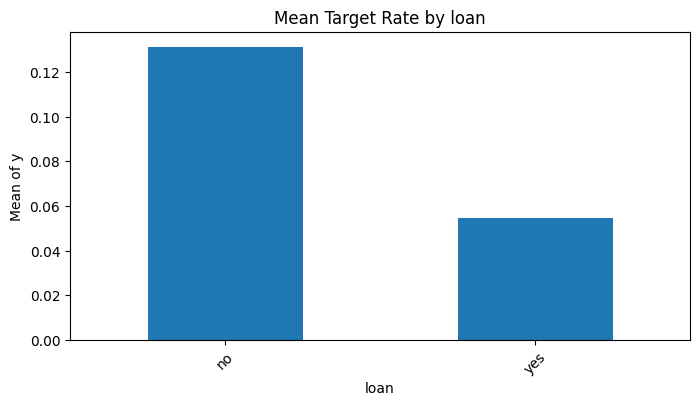

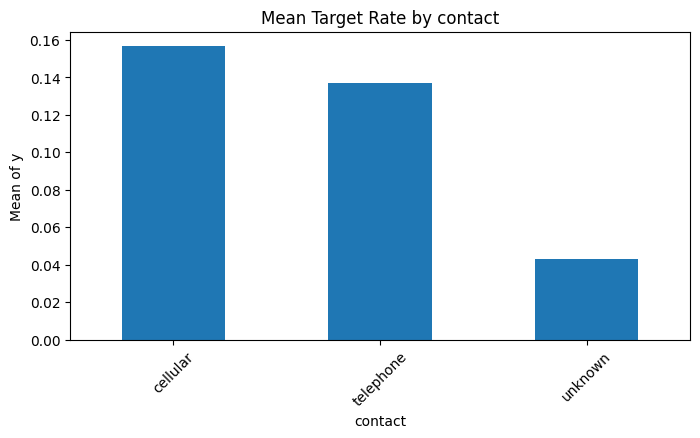

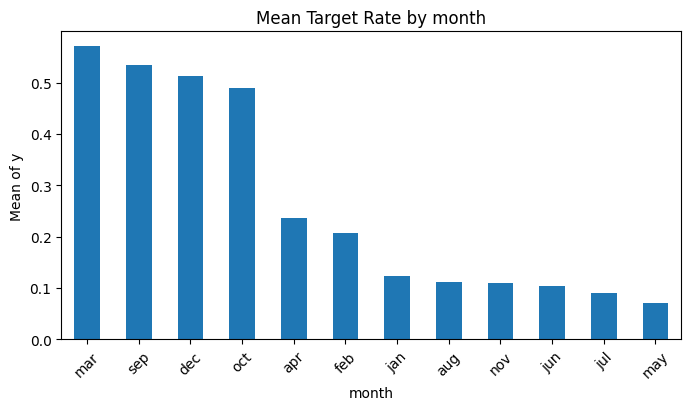

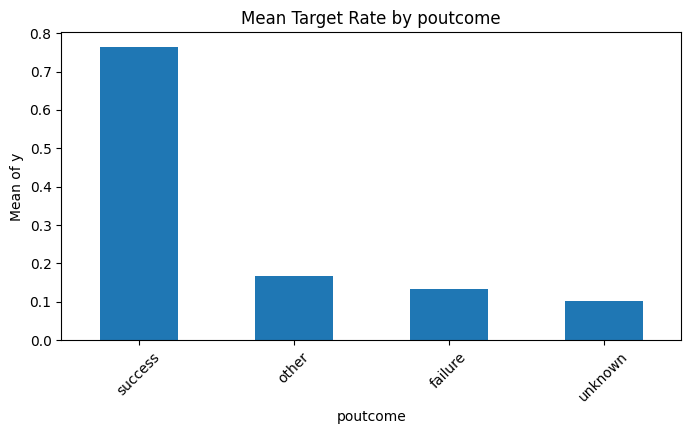

In [14]:
# 셀 14: 범주형 변수별 타깃 평균 시각화
for col in cat_cols:
    temp = train.groupby(col)[target_col].mean().sort_values(ascending=False)

    plt.figure(figsize=(8, 4))
    temp.plot(kind='bar')
    plt.title(f'Mean Target Rate by {col}')
    plt.ylabel('Mean of y')
    plt.xticks(rotation=45)
    plt.show()

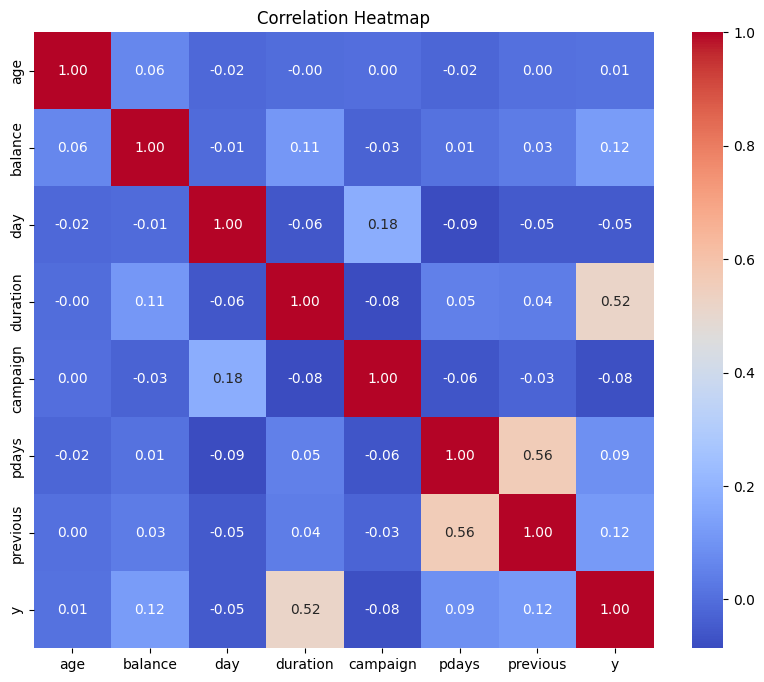

In [15]:
# 셀 15: 수치형 변수 상관계수 히트맵
corr = train[num_cols + [target_col]].corr()

plt.figure(figsize=(10, 8))
sns.heatmap(corr, annot=True, fmt='.2f', cmap='coolwarm')
plt.title('Correlation Heatmap')
plt.show()

In [16]:
# 셀 16: train/test 컬럼 비교
train_cols = set(train.columns)
test_cols = set(test.columns)

print("train에만 있는 컬럼:", train_cols - test_cols)
print("test에만 있는 컬럼:", test_cols - train_cols)

train에만 있는 컬럼: {'y'}
test에만 있는 컬럼: set()


In [17]:
# 셀 17: 범주형 변수별 train/test 범주 차이 확인
for col in cat_cols:
    train_levels = set(train[col].astype(str).unique())
    test_levels = set(test[col].astype(str).unique())

    only_train = train_levels - test_levels
    only_test = test_levels - train_levels

    print(f"\n=== {col} ===")
    print("train에만 있는 범주:", only_train)
    print("test에만 있는 범주:", only_test)


=== job ===
train에만 있는 범주: set()
test에만 있는 범주: set()

=== marital ===
train에만 있는 범주: set()
test에만 있는 범주: set()

=== education ===
train에만 있는 범주: set()
test에만 있는 범주: set()

=== default ===
train에만 있는 범주: set()
test에만 있는 범주: set()

=== housing ===
train에만 있는 범주: set()
test에만 있는 범주: set()

=== loan ===
train에만 있는 범주: set()
test에만 있는 범주: set()

=== contact ===
train에만 있는 범주: set()
test에만 있는 범주: set()

=== month ===
train에만 있는 범주: set()
test에만 있는 범주: set()

=== poutcome ===
train에만 있는 범주: set()
test에만 있는 범주: set()


In [18]:
# 셀 18: 실무형 EDA 요약 테이블 생성
eda_summary = pd.DataFrame({
    'column': train.columns,
    'dtype': train.dtypes.astype(str).values,
    'n_unique': [train[col].nunique() for col in train.columns],
    'missing_count': [train[col].isnull().sum() for col in train.columns],
    'missing_ratio(%)': [round(train[col].isnull().mean() * 100, 2) for col in train.columns]
})

eda_summary['sample_values'] = [train[col].dropna().astype(str).unique()[:5].tolist() for col in train.columns]

display(eda_summary)

,column,dtype,n_unique,missing_count,missing_ratio(%),sample_values
0,id,int64,750000,0,0.0,"[0, 1, 2, 3, 4]"
1,age,int64,78,0,0.0,"[42, 38, 36, 27, 26]"
2,job,object,12,0,0.0,"[technician, blue-collar, student, admin., man..."
3,marital,object,3,0,0.0,"[married, single, divorced]"
4,education,object,4,0,0.0,"[secondary, primary, tertiary, unknown]"
5,default,object,2,0,0.0,"[no, yes]"
6,balance,int64,8217,0,0.0,"[7, 514, 602, 34, 889]"
7,housing,object,2,0,0.0,"[no, yes]"
8,loan,object,2,0,0.0,"[no, yes]"
9,contact,object,3,0,0.0,"[cellular, unknown, telephone]"
